# CPU vs CUDA: train a CNN and measure the difference

**Goal:** train a real convolutional neural network (CNN) to recognize handwritten digits,
run the same training on CPU and NVIDIA GPU, and explain a measured performance report.
All convolution filters and classifier weights are learned through backpropagation.

**Prerequisites:** Python functions, loops, array shapes, and basic classification.
Allow 60–90 minutes to study; the default experiment is deliberately small.
Read each explanation, predict the result, run the cell, then change one setting.

### Learning path

1. Check the environment and understand CPU/GPU work.
2. Prepare labeled images and inspect their tensor shapes.
3. Build a CNN and perform one training step.
4. Write training/evaluation loops with `tqdm` progress bars.
5. Benchmark equal workloads with warm-up, CUDA synchronization, and repeated trials.
6. Display timings, throughput, loss, accuracy, memory, charts, and example predictions.

No dataset download is needed: scikit-learn includes the small digits dataset.
This is a learning benchmark, not a claim about large-scale vision training or other hardware.

## 1. Install once, then restart the kernel

Select this project's `.venv` kernel. The base project already provides NumPy, pandas,
Matplotlib, and scikit-learn. This lesson additionally needs **PyTorch** and **tqdm**
(the progress-bar package; spelled `tqdm`). `ipywidgets` enables notebook-style bars.

Install a PyTorch build suitable for your NVIDIA GPU and driver using the
[official installer](https://pytorch.org/get-started/locally/). The following is a pinned
CUDA 12.8 example for supported Windows/Linux machines, including the development machine's RTX 5070.
Run these in separate notebook cells **once**, then restart the kernel:

```python
%pip install torch==2.10.0 --index-url https://download.pytorch.org/whl/cu128
%pip install tqdm==4.67.3 ipywidgets
```

For a CPU-only Windows/Linux installation, use the `https://download.pytorch.org/whl/cpu`
index instead. macOS users should follow the installer; this lesson compares CPU and NVIDIA CUDA,
so it does not benchmark Apple's MPS backend. Package installation is not part of the timing.
These are lesson-specific environment additions, not dependencies in the base Poetry lockfile.

`nvidia-smi` reports the GPU and driver; `torch.version.cuda` reports the CUDA version in the
PyTorch build. Their version strings need not match. `torch.cuda.is_available()` checks runtime
availability; the benchmark also runs an actual CUDA workload before accepting GPU results.
If CUDA is unavailable, the CPU lesson still runs and the report marks GPU results as skipped.

In [1]:
import copy
import gc
import json
import os
import platform
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

try:
    import torch
    from torch import nn
    from torch.nn import functional as F
    from torch.utils.data import DataLoader, TensorDataset
    from tqdm.auto import tqdm
except ImportError as exc:
    raise ImportError("Install PyTorch and tqdm using section 1, then restart the kernel.") from exc

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__, "| PyTorch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.13.12
PyTorch: 2.10.0+cu128 | PyTorch CUDA build: 12.8
CUDA available: True
GPU: NVIDIA GeForce RTX 5070


### CPU, GPU, and what gets timed

A CPU handles general-purpose work, including Python and preparing batches. A GPU can execute
many tensor operations in parallel, but transferring inputs and launching kernels costs time.
A small CNN can run faster on CPU. Predict which device will win **before** measuring.

We compare FP32 training using identical images, labels, batch size, model weights, optimizer,
epoch count, and shuffle order. The CPU uses a recorded number of threads. CUDA uses one GPU.
Mixed precision, compilation, and TF32 acceleration are disabled in this baseline.
Seeds improve repeatability; they do not guarantee bit-identical CPU and GPU results.

| Measurement | Included | Excluded |
|---|---|---|
| Training seconds | Batch loading, CPU→device copies, forward/backward pass, Adam updates, device-side metrics, batch progress updates | Data preparation, model construction, warm-up, evaluation, plots, epoch summaries |
| Evaluation seconds | Held-out batches, transfers, inference, device-side metrics | Training, plotting, final prediction copy to CPU |
| Images/second | Training images processed across all epochs / training seconds | Evaluation images |
| Peak CUDA allocated MiB | Live PyTorch tensor allocations during measured training, including model/gradients/optimizer | CPU RAM, allocator reservation, other processes, driver/context memory |

CUDA work is asynchronous. Synchronize before and after each measured epoch so the timer waits
for actual GPU completion. Progress bars show batches submitted; the epoch summary reflects completed work.
We avoid `loss.item()` inside the batch loop because it forces a GPU-to-CPU synchronization.

In [2]:
SEED = 42
EPOCHS = 5
REPEATS = 3
BATCH_SIZE = 64
IMAGE_SIZE = 32
LEARNING_RATE = 0.001
WARMUP_STEPS = 3
CPU_THREADS = min(4, os.cpu_count() or 1)
SHOW_PROGRESS = True
RUN_CUDA = True  # False lets you explicitly exercise the CPU-only path.
SAVE_REPORT = False  # Set True to export measured tables and environment metadata.

assert EPOCHS >= 1 and REPEATS >= 1 and BATCH_SIZE >= 1
assert IMAGE_SIZE >= 8 and IMAGE_SIZE % 4 == 0 and WARMUP_STEPS >= 1
torch.set_num_threads(CPU_THREADS)
torch.manual_seed(SEED)
torch.set_float32_matmul_precision("highest")
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
np.random.seed(SEED)

environment = {
    "python": platform.python_version(),
    "platform": platform.platform(),
    "cpu": platform.processor() or "Not reported by OS",
    "cpu_threads": torch.get_num_threads(),
    "torch": str(torch.__version__),
    "cuda_build": torch.version.cuda,
    "cudnn": torch.backends.cudnn.version(),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "precision": "FP32; TF32 disabled; no AMP; no torch.compile",
    "epochs": EPOCHS,
    "repeats": REPEATS,
    "batch_size": BATCH_SIZE,
    "image_size": IMAGE_SIZE,
    "learning_rate": LEARNING_RATE,
    "seed": SEED,
    "warmup_steps": WARMUP_STEPS,
    "workers": 0,
    "progress": SHOW_PROGRESS,
    "run_cuda": RUN_CUDA,
}
display(pd.Series(environment, name="Benchmark configuration").to_frame())

,Benchmark configuration
python,3.13.12
platform,Windows-11-10.0.26200-SP0
cpu,"AMD64 Family 25 Model 97 Stepping 2, AuthenticAMD"
cpu_threads,4
torch,2.10.0+cu128
cuda_build,12.8
cudnn,91002
gpu,NVIDIA GeForce RTX 5070
precision,FP32; TF32 disabled; no AMP; no torch.compile
epochs,5


## 2. Prepare images and labels

Each sample is an 8×8 grayscale image labeled 0–9. Normalize using the dataset's known pixel
range 0–16, then resize to 32×32 to create a slightly larger convolution workload.
Upscaling adds computation, **not new visual information**.

PyTorch convolutions use **NCHW**: batch size, channels, height, width. Our images have one
channel. Labels are integer class indices, not one-hot vectors. We use a stratified 80/20 split
to preserve class proportions; the held-out split never contributes gradients.
No learned preprocessing is fitted on the held-out images.

Training: 1437 | Held-out: 360
Images: torch.Size([1797, 1, 32, 32]) | Labels: torch.Size([1797])


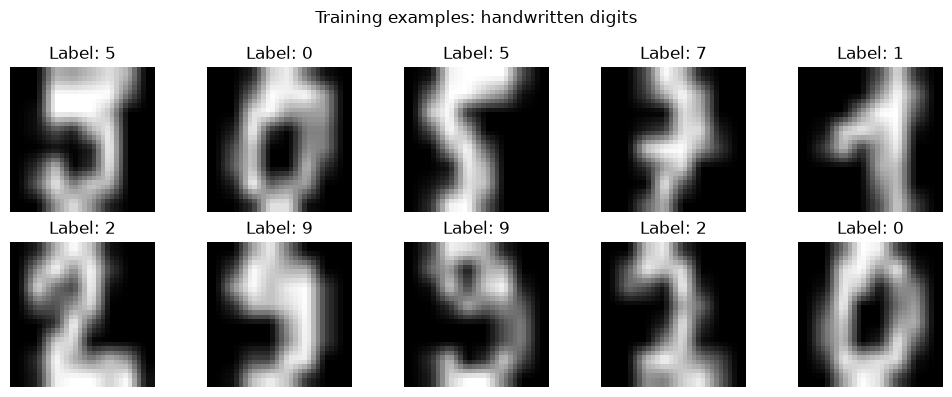

In [3]:
digits = load_digits()
train_ids, test_ids = train_test_split(
    np.arange(len(digits.target)), test_size=0.2, random_state=SEED, stratify=digits.target
)
images = torch.tensor(digits.images, dtype=torch.float32).unsqueeze(1) / 16.0
images = F.interpolate(images, size=(IMAGE_SIZE, IMAGE_SIZE), mode="bilinear", align_corners=False)
labels = torch.tensor(digits.target, dtype=torch.long)
train_data = TensorDataset(images[train_ids], labels[train_ids])
test_data = TensorDataset(images[test_ids], labels[test_ids])
assert set(train_ids).isdisjoint(test_ids)
assert train_data.tensors[0].shape[1:] == (1, IMAGE_SIZE, IMAGE_SIZE)
assert labels.dtype == torch.long and images.dtype == torch.float32
environment.update(train_samples=len(train_data), test_samples=len(test_data))
print("Training:", len(train_data), "| Held-out:", len(test_data))
print("Images:", images.shape, "| Labels:", labels.shape)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, index in zip(axes.flat, train_ids[:10]):
    ax.imshow(images[index, 0], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Label: {labels[index].item()}")
    ax.axis("off")
fig.suptitle("Training examples: handwritten digits")
fig.tight_layout()
plt.show()

## 3. Build the CNN

1. **Conv2d:** learn local filters that respond to useful image patterns.
2. **ReLU:** introduce nonlinearity so the network can learn more than a linear mapping.
3. **MaxPool2d:** halve spatial dimensions, retaining strong local responses.
4. Repeat the convolution block, flatten the feature maps, and predict ten class scores.

For 32×32 inputs: `(N, 1, 32, 32) → (N, 16, 16, 16) → (N, 32, 8, 8) → (N, 10)`.
Outputs are **logits**, unnormalized scores. `CrossEntropyLoss` handles the required log-softmax;
do not add a softmax layer before that loss. `argmax` gives the predicted class.

**Predict:** What happens to the first linear layer's input size if `IMAGE_SIZE` doubles?

In [4]:
class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(32 * (IMAGE_SIZE // 4) ** 2, 64), nn.ReLU(), nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


torch.manual_seed(SEED)
template = DigitCNN()
INITIAL_STATE = copy.deepcopy(template.state_dict())  # CPU snapshot shared by every trial
parameter_count = sum(p.numel() for p in template.parameters())
assert template(images[:4]).shape == (4, 10)
environment["parameters"] = parameter_count
print(template)
print(f"Trainable parameters: {parameter_count:,}")
del template

DigitCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)
Trainable parameters: 136,586


## 4. Understand one training step

`zero_grad` clears old gradients → forward computes logits → loss measures error →
`backward` computes gradients → `step` updates weights.
We demonstrate on a disposable CPU model so the benchmark's initial state stays untouched.

**Checkpoint:** Removing `optimizer.step()` still produces a loss, but does it train the network?

In [5]:
demo = DigitCNN()
demo.load_state_dict(INITIAL_STATE)
demo_optimizer = torch.optim.Adam(demo.parameters(), lr=LEARNING_RATE)
demo_x, demo_y = train_data.tensors[0][:BATCH_SIZE], train_data.tensors[1][:BATCH_SIZE]
before = demo.features[0].weight.detach().clone()
demo_optimizer.zero_grad(set_to_none=True)
demo_logits = demo(demo_x)
demo_loss = nn.CrossEntropyLoss()(demo_logits, demo_y)
demo_loss.backward()
assert demo.features[0].weight.grad is not None
demo_optimizer.step()
assert not torch.equal(before, demo.features[0].weight)
print(f"Initial batch loss: {demo_loss.item():.4f}; convolution weights changed.")
del demo, demo_optimizer, demo_logits, demo_loss, before

Initial batch loss: 2.3019; convolution weights changed.


## 5. Reusable data and training loops

A **batch** is a group of images; an **epoch** is one complete pass over training data.
Every trial creates a fresh seeded loader, so it sees the same batch order in every epoch.
`num_workers=0` avoids notebook multiprocessing issues on Windows.
For CUDA, pinned host memory and nonblocking copies are enabled; these settings are part of
the reported pipeline, not evidence that transfers fully overlap computation.

`tqdm.auto` selects a notebook or text progress bar. It reports completed loop iterations,
elapsed time, and estimated time remaining. Epoch-end summaries add loss, accuracy, and timing.
Set `SHOW_PROGRESS=False` to study progress-display overhead.

We accumulate sample-weighted loss and correct predictions on the device, handling the last,
smaller batch correctly. Evaluation uses `model.eval()` and `inference_mode()` without updates.

In [6]:
def synchronize(device):
    if device.type == "cuda":
        torch.cuda.synchronize(device)


def make_loader(dataset, device, shuffle=False):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=device.type == "cuda",
        drop_last=False,
        generator=torch.Generator().manual_seed(SEED),
    )


def train_epoch(model, loader, optimizer, device, description):
    model.train()
    loss_sum = torch.zeros((), device=device)
    correct = torch.zeros((), dtype=torch.long, device=device)
    count = 0
    synchronize(device)
    start = time.perf_counter()
    with tqdm(
        loader,
        desc=description,
        unit="batch",
        leave=False,
        disable=not SHOW_PROGRESS,
        mininterval=0.5,
    ) as batches:
        for x, y in batches:
            x = x.to(device, non_blocking=device.type == "cuda")
            y = y.to(device, non_blocking=device.type == "cuda")
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            optimizer.step()
            loss_sum += loss.detach() * y.size(0)
            correct += (logits.detach().argmax(1) == y).sum()
            count += y.size(0)
    synchronize(device)
    seconds = time.perf_counter() - start
    return {
        "loss": loss_sum.item() / count,
        "accuracy": correct.item() / count,
        "seconds": seconds,
        "samples": count,
    }


@torch.inference_mode()
def evaluate(model, loader, device):
    model.eval()
    loss_sum = torch.zeros((), device=device)
    correct = torch.zeros((), dtype=torch.long, device=device)
    predicted = []
    count = 0
    synchronize(device)
    start = time.perf_counter()
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss_sum += F.cross_entropy(logits, y, reduction="sum")
        prediction = logits.argmax(1)
        correct += (prediction == y).sum()
        predicted.append(prediction)
        count += y.size(0)
    synchronize(device)
    seconds = time.perf_counter() - start
    return {
        "loss": loss_sum.item() / count,
        "accuracy": correct.item() / count,
        "seconds": seconds,
        "predictions": torch.cat(predicted).cpu().numpy(),
    }

## 6. Warm up without giving one device extra training

The first operation can initialize libraries and device resources. Warm up using actual
forward/backward/optimizer steps, then restore the original weights and create a **fresh optimizer**.
Resetting weights alone would leave Adam's momentum estimates from warm-up.
This model has no dropout or batch normalization; its saved state fully describes its parameters.

The measured first epoch still includes fresh optimizer-state allocation and may be slower than
later epochs. We report every epoch as well as total training time; this is not a pure kernel benchmark.
GPU memory is sampled before evaluation so predictions do not inflate training memory.

In [7]:
def run_trial(device_name, trial):
    device = torch.device(device_name)
    torch.manual_seed(SEED)
    model = DigitCNN().to(device)
    model.load_state_dict(INITIAL_STATE)
    warm_optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    warm_x = train_data.tensors[0][:BATCH_SIZE].to(device)
    warm_y = train_data.tensors[1][:BATCH_SIZE].to(device)
    model.train()
    for _ in range(WARMUP_STEPS):
        warm_optimizer.zero_grad(set_to_none=True)
        F.cross_entropy(model(warm_x), warm_y).backward()
        warm_optimizer.step()
    synchronize(device)
    del warm_optimizer, warm_x, warm_y
    model.load_state_dict(INITIAL_STATE)
    model.zero_grad(set_to_none=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    train_loader = make_loader(train_data, device, shuffle=True)
    test_loader = make_loader(test_data, device)
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)

    epoch_rows = []
    for epoch in range(1, EPOCHS + 1):
        metrics = train_epoch(
            model,
            train_loader,
            optimizer,
            device,
            f"{device_name} trial {trial} epoch {epoch}/{EPOCHS}",
        )
        assert metrics["samples"] == len(train_data)
        epoch_rows.append({"device": device_name, "trial": trial, "epoch": epoch, **metrics})
        if SHOW_PROGRESS:
            tqdm.write(
                f"{device_name} | trial {trial} | epoch {epoch}: "
                f"loss={metrics['loss']:.4f}, accuracy={metrics['accuracy']:.1%}, "
                f"{metrics['seconds']:.3f}s"
            )
    peak_mib = torch.cuda.max_memory_allocated(device) / 2**20 if device.type == "cuda" else np.nan
    evaluation = evaluate(model, test_loader, device)
    train_seconds = sum(row["seconds"] for row in epoch_rows)
    row = {
        "device": device_name,
        "trial": trial,
        "train_seconds": train_seconds,
        "images_per_second": len(train_data) * EPOCHS / train_seconds,
        "final_train_loss": epoch_rows[-1]["loss"],
        "final_train_accuracy": epoch_rows[-1]["accuracy"],
        "test_loss": evaluation["loss"],
        "test_accuracy": evaluation["accuracy"],
        "eval_seconds": evaluation["seconds"],
        "peak_cuda_allocated_mib": peak_mib,
    }
    predictions = evaluation["predictions"]
    del model, optimizer, train_loader, test_loader
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()  # Cleanup between trials, never inside the measured loop.
    return row, epoch_rows, predictions

## 7. Run the CPU / CUDA comparison

Run three trials per device and alternate which device runs first to reduce ordering bias.
Weights and data order stay fixed across trials, so repetition measures timing variability,
not robustness across random seeds. Close unrelated heavy workloads for a less noisy measurement.

If CUDA is missing, disabled, or fails (for example, an incompatible build or insufficient memory),
the final report includes the reason and retains valid CPU results. It never substitutes CPU timings
under a GPU label. Reduce `BATCH_SIZE` or `IMAGE_SIZE` after an out-of-memory error and rerun from settings.
Keep the same new settings for both devices.

In [8]:
trial_rows, epoch_rows, example_predictions = [], [], {}
cuda_reason = None
devices = ["cpu"]
if RUN_CUDA and torch.cuda.is_available():
    devices.append("cuda:0")
else:
    cuda_reason = (
        "Disabled by RUN_CUDA=False" if not RUN_CUDA else "CUDA unavailable in this kernel"
    )

for trial in range(1, REPEATS + 1):
    order = devices.copy() if trial % 2 else list(reversed(devices))
    for device_name in order:
        if device_name == "cuda:0" and cuda_reason is not None:
            continue
        try:
            row, history, prediction = run_trial(device_name, trial)
        except RuntimeError as exc:
            if device_name == "cpu":
                raise
            cuda_reason = f"CUDA runtime failed: {exc}"
            print(cuda_reason)
            # Exclude partial CUDA trial sets from the aggregate comparison.
            trial_rows = [r for r in trial_rows if r["device"] != "cuda:0"]
            epoch_rows = [r for r in epoch_rows if r["device"] != "cuda:0"]
            example_predictions.pop("cuda:0", None)
            gc.collect()
            continue
        trial_rows.append(row)
        epoch_rows.extend(history)
        if trial == 1:
            example_predictions[device_name] = prediction

trials = pd.DataFrame(trial_rows)
history = pd.DataFrame(epoch_rows)
assert len(trials[trials.device == "cpu"]) == REPEATS
assert np.isfinite(trials[["train_seconds", "test_loss", "test_accuracy"]].to_numpy()).all()
assert trials.test_accuracy.between(0, 1).all() and (trials.train_seconds > 0).all()
print("Finished. The report below uses these measured results.")

cpu trial 1 epoch 1/5:   0%|          | 0/23 [00:00<?, ?batch/s]

cpu | trial 1 | epoch 1: loss=2.1151, accuracy=33.8%, 0.164s


cpu trial 1 epoch 2/5:   0%|          | 0/23 [00:00<?, ?batch/s]

cpu | trial 1 | epoch 2: loss=1.0023, accuracy=75.6%, 0.155s


cpu trial 1 epoch 3/5:   0%|          | 0/23 [00:00<?, ?batch/s]

...

cuda:0 trial 3 epoch 4/5:   0%|          | 0/23 [00:00<?, ?batch/s]

cuda:0 | trial 3 | epoch 4: loss=0.2503, accuracy=92.0%, 0.055s


cuda:0 trial 3 epoch 5/5:   0%|          | 0/23 [00:00<?, ?batch/s]

cuda:0 | trial 3 | epoch 5: loss=0.2090, accuracy=92.8%, 0.056s


Finished. The report below uses these measured results.


## 8. Final benchmark report

**Speedup = median CPU training seconds / median device training seconds.** Above 1 means
faster than CPU for this workload; below 1 means slower. CPU is the 1× reference.
Accuracy is shown as a percentage. Min/max timings expose noise hidden by a single median.
Peak CUDA allocated memory is the maximum across trials; CPU memory is not measured.

The held-out accuracy checks whether the trained model learned useful image features.
Training accuracy is collected while weights change within an epoch; held-out accuracy is evaluated
using final weights, so these are not exactly the same measurement. Do not pick hyperparameters
repeatedly on this held-out set—use a separate validation split for tuning.

In [9]:
summary = trials.groupby("device", sort=False).agg(
    trials=("trial", "count"),
    train_s_median=("train_seconds", "median"),
    train_s_min=("train_seconds", "min"),
    train_s_max=("train_seconds", "max"),
    images_s_median=("images_per_second", "median"),
    final_train_loss=("final_train_loss", "median"),
    test_loss=("test_loss", "median"),
    test_accuracy_pct=("test_accuracy", lambda values: 100 * values.median()),
    eval_s_median=("eval_seconds", "median"),
    peak_cuda_allocated_mib=("peak_cuda_allocated_mib", "max"),
)
summary["speedup_vs_cpu"] = summary.loc["cpu", "train_s_median"] / summary.train_s_median
summary["status"] = "completed"
if cuda_reason is not None:
    summary.loc["cuda:0", "status"] = f"Skipped: {cuda_reason}"

display(Markdown("### Measured results"))
display(summary.round(3))
display(Markdown("### Individual trials (timing variability)"))
display(trials.round(4))
majority_class = torch.bincount(train_data.tensors[1]).argmax().item()
baseline_accuracy = (test_data.tensors[1].numpy() == majority_class).mean()
print(f"Majority-class baseline held-out accuracy: {baseline_accuracy:.1%}")
if cuda_reason is None:
    speedup = summary.loc["cuda:0", "speedup_vs_cpu"]
    print(f"CPU / CUDA median training-time ratio: {speedup:.2f}x.")
    print(
        "CUDA was faster for this workload."
        if speedup > 1
        else "CPU was at least as fast for this workload; overhead can dominate small models."
    )
    gap = abs(summary.loc["cpu", "test_accuracy_pct"] - summary.loc["cuda:0", "test_accuracy_pct"])
    print(f"CPU/GPU held-out accuracy difference: {gap:.2f} percentage points.")
else:
    print("GPU speedup is not available:", cuda_reason)
print("Timings apply only to the hardware, settings, and workload recorded here.")
display(pd.Series(environment, name="Environment").to_frame())

### Measured results

,trials,train_s_median,train_s_min,train_s_max,images_s_median,final_train_loss,test_loss,test_accuracy_pct,eval_s_median,peak_cuda_allocated_mib,speedup_vs_cpu,status
device,,,,,,,,,,,,
cpu,3,0.770,0.764,0.787,9335.648,0.209,0.21,94.167,0.023,NaN,1.000,completed
cuda:0,3,0.286,0.270,0.296,25155.916,0.209,0.21,94.167,0.006,36.397,2.695,completed


### Individual trials (timing variability)

,device,trial,train_seconds,images_per_second,final_train_loss,final_train_accuracy,test_loss,test_accuracy,eval_seconds,peak_cuda_allocated_mib
0,cpu,1,0.7868,9131.8444,0.2091,0.9283,0.2104,0.9417,0.0217,NaN
1,cuda:0,1,0.2957,24299.4915,0.2090,0.9283,0.2100,0.9417,0.0108,36.3975
2,cuda:0,2,0.2856,25155.9159,0.2090,0.9283,0.2100,0.9417,0.0056,36.3975
3,cpu,2,0.7696,9335.6475,0.2091,0.9283,0.2104,0.9417,0.0226,NaN
4,cpu,3,0.7636,9409.4493,0.2091,0.9283,0.2104,0.9417,0.0232,NaN
5,cuda:0,3,0.2703,26582.4611,0.2090,0.9283,0.2100,0.9417,0.0047,36.3975


Majority-class baseline held-out accuracy: 10.0%
CPU / CUDA median training-time ratio: 2.69x.
CUDA was faster for this workload.
CPU/GPU held-out accuracy difference: 0.00 percentage points.
Timings apply only to the hardware, settings, and workload recorded here.


,Environment
python,3.13.12
platform,Windows-11-10.0.26200-SP0
cpu,"AMD64 Family 25 Model 97 Stepping 2, AuthenticAMD"
cpu_threads,4
torch,2.10.0+cu128
cuda_build,12.8
cudnn,91002
gpu,NVIDIA GeForce RTX 5070
precision,FP32; TF32 disabled; no AMP; no torch.compile
epochs,5


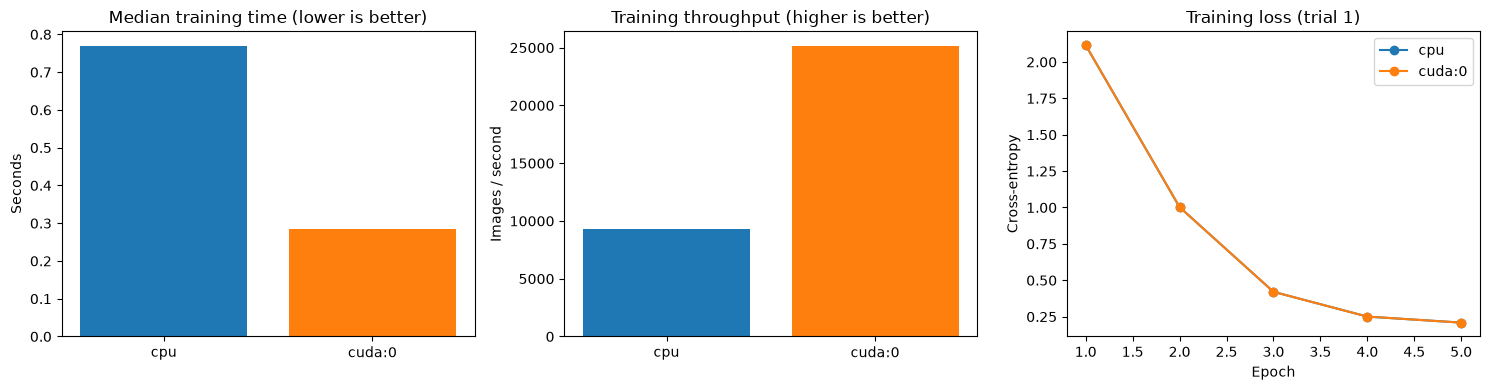

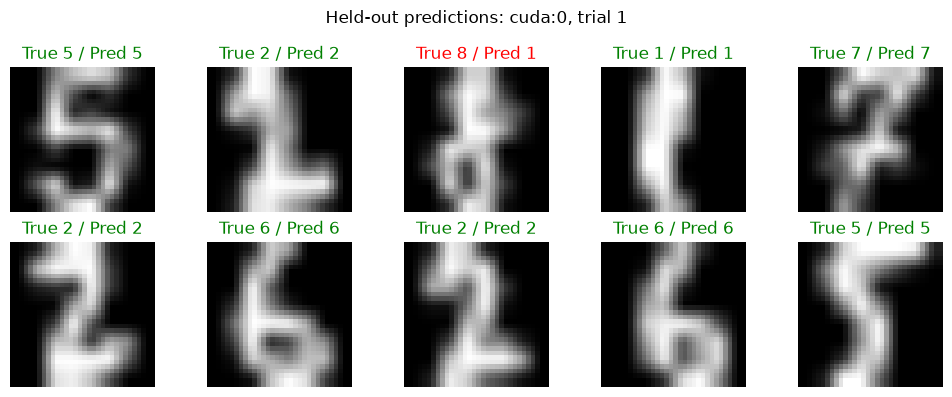

In [10]:
completed = summary[summary.status == "completed"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(
    completed.index, completed.train_s_median, color=["tab:blue", "tab:orange"][: len(completed)]
)
axes[0].set(title="Median training time (lower is better)", ylabel="Seconds")
axes[1].bar(
    completed.index, completed.images_s_median, color=["tab:blue", "tab:orange"][: len(completed)]
)
axes[1].set(title="Training throughput (higher is better)", ylabel="Images / second")
for device_name, group in history[history.trial == 1].groupby("device"):
    axes[2].plot(group.epoch, group.loss, marker="o", label=device_name)
axes[2].set(title="Training loss (trial 1)", xlabel="Epoch", ylabel="Cross-entropy")
axes[2].legend()
fig.tight_layout()
plt.show()

# Inspect a fixed trial, not the best-scoring trial selected after looking at test data.
display_device = "cuda:0" if "cuda:0" in example_predictions else "cpu"
prediction = example_predictions[display_device]
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    actual = test_data.tensors[1][i].item()
    ax.imshow(test_data.tensors[0][i, 0], cmap="gray", vmin=0, vmax=1)
    ax.set_title(
        f"True {actual} / Pred {prediction[i]}", color="green" if actual == prediction[i] else "red"
    )
    ax.axis("off")
fig.suptitle(f"Held-out predictions: {display_device}, trial 1")
fig.tight_layout()
plt.show()

### Optional: save your measured report

Set `SAVE_REPORT=True` in settings. Files go into a timestamped directory under the repository's
`reports/cuda_benchmark/`, preserving earlier experiments. CSV files contain numbers; JSON records
the hardware/settings and any CUDA failure reason. The displayed report always works without export.

In [11]:
if SAVE_REPORT:
    from datetime import datetime, timezone

    repo_root = next(
        (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()),
        Path.cwd(),
    )
    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
    output_dir = repo_root / "reports" / "cuda_benchmark" / stamp
    output_dir.mkdir(parents=True, exist_ok=False)
    summary.to_csv(output_dir / "summary.csv")
    trials.to_csv(output_dir / "trials.csv", index=False)
    history.to_csv(output_dir / "epochs.csv", index=False)
    (output_dir / "environment.json").write_text(
        json.dumps({**environment, "cuda_status": cuda_reason or "completed"}, indent=2),
        encoding="utf-8",
    )
    print("Report saved to:", output_dir.resolve())

## 9. Experiments: predict, change one thing, rerun

Rerun from the settings cell after each change so the model and report use the same configuration.

1. **Batch size:** try 16, 64, and 256. Compare throughput and accuracy. Larger batches mean
   fewer optimizer updates per epoch, so this changes the learning process as well as hardware use.
2. **Image size:** compare 8, 32, and 64. Does extra convolution work improve GPU utilization?
   Upscaling does not add information and changes the classifier's parameter count here.
3. **Epochs:** compare 1 and 10. Inspect loss and discuss how first-epoch overhead affects total time.
4. **Progress overhead:** set `SHOW_PROGRESS=False`. Do the measured ratios change?
5. **CPU threads:** compare 1, 2, and 4. More threads need not help a small workload.
6. **CPU-only behavior:** set `RUN_CUDA=False`. Verify the report shows no GPU speedup.

**Stretch task:** after adding a validation split, try mixed precision on CUDA and label that
as a separate experiment. Do not present it as the same FP32 comparison.
For a real-photo extension, use the official CIFAR-10 tutorial; use three input channels and
keep downloads/augmentation outside the timing or explicitly report their costs.

### Write your conclusion

- My CPU / GPU and settings were …
- Median training time was … and the range across trials was …
- The speedup ratio was …; a plausible reason is …
- The model's held-out accuracy compared with the majority baseline was …
- This experiment does not establish …

### Checkpoint answers

- Doubling image width and height quadruples the flattened input size of the first linear layer.
- Without `optimizer.step()`, gradients are computed but model parameters are not updated.
- A progress bar or a CPU timer alone does not prove GPU computation has completed.
- Identical seeds and weights do not guarantee identical floating-point results on CPU and GPU.

## References

- [PyTorch: training an image classifier](https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html)
  — further reading for a CNN on real RGB images.
- [CUDA synchronization](https://docs.pytorch.org/docs/stable/generated/torch.cuda.synchronize.html)
  and [CUDA execution semantics](https://docs.pytorch.org/docs/stable/notes/cuda.html)
  — why benchmark boundaries must wait for queued GPU work.
- [PyTorch reproducibility](https://docs.pytorch.org/docs/stable/notes/randomness.html)
  — seeds, algorithm selection, and cross-platform limitations.
- [scikit-learn digits dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html)
  — dataset format and pixel range.
- [tqdm notebook/auto shortcuts](https://tqdm.github.io/docs/shortcuts/)
  — notebook and terminal progress bars.
- [Official version-specific PyTorch installation commands](https://pytorch.org/get-started/previous-versions/)
  — source for the pinned CUDA 12.8 installation example.